In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from datetime import timedelta
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

### **1. Tải và làm sạch dữ liệu**

In [2]:
# Đọc file dữ liệu và chuẩn hóa toàn bộ tên cột về snake_case
def to_snake(name):
    name = str(name).strip()
    name = re.sub(r'[^0-9a-zA-Z]+', '_', name)
    name = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', name)
    name = re.sub(r'_+', '_', name).strip('_')
    return name.lower()

file_candidates = [
    "Online_Retail.xlsx",
    "Online_Retail (1).xlsx",
    "/mnt/data/Online_Retail.xlsx",
    "/mnt/data/Online_Retail (1).xlsx"
]
file_path = next((f for f in file_candidates if os.path.exists(f)), None)
if file_path is None:
    raise FileNotFoundError("Không tìm thấy file Online_Retail.xlsx trong thư mục làm việc.")

df_raw = pd.read_excel(file_path)
df_raw.columns = [to_snake(col) for col in df_raw.columns]
df_raw['invoice_date'] = pd.to_datetime(df_raw['invoice_date'])

print(f"Đã đọc file: {file_path}")
print("Shape dữ liệu thô:", df_raw.shape)
display(df_raw.head())

# Tạo bản làm việc để làm sạch
df = df_raw.copy()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Kiểm toán dữ liệu (Data Audit) trước khi làm sạch
audit_table = pd.DataFrame([
    {"check": "raw_rows", "value": len(df_raw)},
    {"check": "duplicate_rows", "value": int(df_raw.duplicated().sum())},
    {"check": "missing_customer_id", "value": int(df_raw['customer_id'].isna().sum())},
    {"check": "cancel_rows", "value": int(df_raw['invoice_no'].astype(str).str.startswith('C', na=False).sum())},
    {"check": "quantity_le_zero", "value": int((df_raw['quantity'] <= 0).sum())},
    {"check": "unit_price_le_zero", "value": int((df_raw['unit_price'] <= 0).sum())},
    {"check": "distinct_customers_raw", "value": int(df_raw['customer_id'].nunique(dropna=True))}
])
display(audit_table)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [ ]:
# Sắp xếp lại thứ tự cột để dễ kiểm tra
current_columns = df.columns.tolist()
print(f"Các cột hiện tại: {current_columns}")

new_column_order = [
    'customer_id', 'invoice_date', 'invoice_no', 'stock_code',
    'description', 'quantity', 'unit_price', 'country'
]
available_columns = [c for c in new_column_order if c in df.columns]
df = df[available_columns]

print("\nDataFrame sau khi sắp xếp lại cột:")
display(df.head())

Các cột hiện tại: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

DataFrame sau khi sắp xếp lại cột:


,CustomerID,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
0,17850.0,2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom
1,17850.0,2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,United Kingdom
2,17850.0,2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
3,17850.0,2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,United Kingdom
4,17850.0,2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,United Kingdom


In [6]:
# Đếm số mặt hàng khác nhau trong tập dữ liệu
df['stock_code'].nunique()

4070

In [7]:
df[df['stock_code'].astype(str).str.contains('B', na=False)]

,CustomerID,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
2,17850.0,2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
51,17850.0,2010-12-01 09:02:00,536373,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
68,17850.0,2010-12-01 09:32:00,536375,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
90,14688.0,2010-12-01 09:37:00,536378,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,12,3.75,United Kingdom
101,14688.0,2010-12-01 09:37:00,536378,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,1.25,United Kingdom
...,...,...,...,...,...,...,...,...
541673,14446.0,2011-12-09 11:34:00,581538,84519B,CARROT CHARLIE+LOLA COASTER SET,1,1.25,United Kingdom
541674,14446.0,2011-12-09 11:34:00,581538,35004B,SET OF 3 BLACK FLYING DUCKS,2,5.45,United Kingdom
541687,14446.0,2011-12-09 11:34:00,581538,79191B,RETRO PLASTIC POLKA TRAY,1,0.85,United Kingdom
541698,14446.0,2011-12-09 11:34:00,581538,35004B,SET OF 3 BLACK FLYING DUCKS,1,5.45,United Kingdom


In [8]:
df.describe()
## Dùng để xác định các thao tác làm sạch dữ liệu tiếp theo
# Cột invoice_date, quantity và unit_price đều có 541,909 dòng. Nhưng cột customer_id chỉ có 406,829 dòng nên phải xóa những dòng bị thiếu Customer ID
# Min (Giá trị nhỏ nhất) của cột quantity bị âm (tức là hàng bị trả lại) thì tí nữa chúng tôi lọc những đơn hàng có quantity âm
# Min của cột unit_price bị âm nên cũng phải lọc unit_price < = 0


,CustomerID,InvoiceDate,Quantity,UnitPrice
count,406829.000000,541909,541909.000000,541909.000000
mean,15287.690570,2011-07-04 13:34:57.156386,9.552250,4.611114
min,12346.000000,2010-12-01 08:26:00,-80995.000000,-11062.060000
25%,13953.000000,2011-03-28 11:34:00,1.000000,1.250000
50%,15152.000000,2011-07-19 17:17:00,3.000000,2.080000
75%,16791.000000,2011-10-19 11:27:00,10.000000,4.130000
max,18287.000000,2011-12-09 12:50:00,80995.000000,38970.000000
std,1713.600303,NaN,218.081158,96.759853


In [9]:
# Loại bỏ trùng lặp và ghi nhận số lượng dòng bị loại
duplicate_count = int(df.duplicated().sum())
print("Số dòng trùng lặp trước khi xóa:", duplicate_count)

df = df.drop_duplicates().copy()

print("Số dòng trùng lặp sau khi xóa:", int(df.duplicated().sum()))
print("Shape sau khi xóa trùng lặp:", df.shape)

5268
0


In [10]:
# Xóa bỏ các dòng dữ liệu thiếu customer_id
missing_customer_rows = int(df['customer_id'].isna().sum())
print("Số dòng thiếu customer_id trước khi xóa:", missing_customer_rows)

df = df.dropna(subset=['customer_id']).copy()
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

print("Shape sau khi xóa missing customer_id:", df.shape)

In [11]:
# Chuẩn hóa kiểu dữ liệu
df['customer_id'] = df['customer_id'].astype(int)
df['invoice_no'] = df['invoice_no'].astype(str)
df['stock_code'] = df['stock_code'].astype(str)

display(df.head())

In [12]:
# Giữ lại toàn bộ dữ liệu đã làm sạch cơ bản để phục vụ feature hành vi hủy / trả hàng
df_full = df.copy()
df_full['total_amount'] = df_full['quantity'] * df_full['unit_price']
df_full['is_cancel'] = df_full['invoice_no'].astype(str).str.startswith('C')
df_full['is_return'] = df_full['quantity'] < 0

print("Shape df_full:", df_full.shape)
display(df_full.head())

In [13]:
# df1 là tập giao dịch hợp lệ dùng để tính RFM / giá trị mua hàng
# Lưu ý: thông tin hủy / trả hàng KHÔNG bị xóa khỏi bài toán, mà được giữ ở df_full để tạo feature hành vi
df1 = df_full[
    (df_full['quantity'] > 0) &
    (df_full['unit_price'] > 0) &
    (~df_full['is_cancel'])
].copy()

print(f"Số dòng đầy đủ (df_full): {len(df_full):,}")
print(f"Số dòng hợp lệ (df1): {len(df1):,}")
print(f"Tỷ lệ giữ lại giao dịch hợp lệ: {len(df1)/len(df_full):.2%}")
print("Số lượng giá trị thiếu trong df_full:")
print(df_full.isnull().sum())

Số dòng đầy đủ (df_full): 401604
Số dòng hợp lệ (df1): 392692
Số lượng giá trị trống trong df_full:
CustomerID     0
InvoiceDate    0
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
Country        0
TotalAmount    0
is_cancel      0
is_return      0
dtype: int64


In [15]:
# Kiểm tra dữ liệu sau khi được làm sạch
df1.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   CustomerID   392692 non-null  int64         
 1   InvoiceDate  392692 non-null  datetime64[us]
 2   InvoiceNo    392692 non-null  object        
 3   StockCode    392692 non-null  object        
 4   Description  392692 non-null  object        
 5   Quantity     392692 non-null  int64         
 6   UnitPrice    392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalAmount  392692 non-null  float64       
 9   is_cancel    392692 non-null  bool          
 10  is_return    392692 non-null  bool          
dtypes: bool(2), datetime64[us](1), float64(2), int64(2), object(3), str(1)
memory usage: 30.7+ MB


In [16]:
# Kiểm tra lại xem còn dữ liệu unit_price < 0
df1[df1['unit_price'] <=0].head()

,CustomerID,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,TotalAmount,is_cancel,is_return


In [17]:
# Kiểm tra dữ liệu lạ
df1['country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',               'Greece',            'Singapore',
              'Lebanon', 'United Arab Emirates',               'Israel',
         'Saudi Arabia',       'Czech Republic',               'Canada',
          'Unspecified',               'Brazil',                  'USA',
   'European Community',              'Bahrain',                'Malta',
                  'RSA']
Length: 37, dtype: str

In [18]:
# Tạo biến total_price trên tập giao dịch hợp lệ
df1['total_price'] = df1['quantity'] * df1['unit_price']

> **Lưu ý quan trọng về Data Leakage:**  
> Phần RFM và phân khúc khách hàng dưới đây chỉ phục vụ **mô tả business / EDA** trên dữ liệu lịch sử đã làm sạch.  
> **Không dùng trực tiếp các kết quả full-history này để huấn luyện mô hình churn.**  
> Phần mô hình churn ở phía sau sẽ dùng **snapshot theo thời gian** để tránh rò rỉ dữ liệu.

In [19]:
# Khảo sát độ dài dữ liệu
print(df1['invoice_date'].min())
print(df1['invoice_date'].max())

# Giữ nguyên df1 full-range để phục vụ bài toán churn 90 ngày
# Tạo riêng một bản cắt thời gian cho phần RFM minh họa
df_rfm = df1[df1['invoice_date'] < '2011-11-30'].copy()

now = df_rfm['invoice_date'].max() + pd.DateOffset(days=1)  # cộng thêm một ngày cho dễ tính recency
now

2010-12-01 08:26:00
2011-12-09 12:50:00


Timestamp('2011-11-30 18:14:00')

In [20]:
# Lập hàm tính recency
lambda x: (now - x.max()).days

<function __main__.<lambda>(x)>

In [21]:
# Tạo R,F,M
rfm = df_rfm.groupby('customer_id').agg(
        Recency = ('invoice_date', lambda x: (now - x.max()).days),
        Frequency = ('invoice_no' , 'nunique'),
        Monetary = ('total_price', 'sum')
          )


In [22]:
#
rfm['r_score'] = pd.qcut(x = rfm['Recency'] , q = 5, labels = [5,4,3,2,1])
rfm['m_score'] = pd.qcut(x = rfm['Monetary'], q = 5 , labels = [1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score
CustomerID,,,,,
12346,316,1,77183.60,1,5
12347,30,6,4085.18,4,5
12348,66,4,1797.24,3,4
12349,9,1,1757.55,5,4
12350,301,1,334.40,1,2


Frequency
1     1545
2      807
3      514
4      379
5      225
6      169
7      134
8       95
9       57
11      51
Name: count, dtype: int64

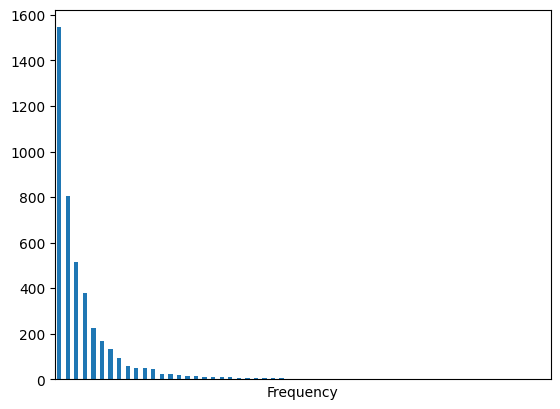

In [50]:
# Kiểm tra Frequency của data thấy được Frequency = 1 là cao nhất sau đó = 2 tức là có rất nhiều khách vãng lai
display(rfm['Frequency'].value_counts().head(10))
rfm['Frequency'].value_counts().plot(kind = 'bar')
plt.xticks([])
plt.show()


In [24]:
# Phân loại khách hàng theo R,F,M score
rfm['f_score'] = pd.qcut(x=rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score
CustomerID,,,,,,
12346,316,1,77183.60,1,5,1
12347,30,6,4085.18,4,5,5
12348,66,4,1797.24,3,4,4
12349,9,1,1757.55,5,4,1
12350,301,1,334.40,1,2,1


In [25]:
# Phân nhóm các khách hàng có cùng Frequency = 1 bằng F score
rfm[rfm["Frequency"]==1]['f_score'].value_counts()

f_score
1    859
2    686
3      0
4      0
5      0
Name: count, dtype: int64

In [26]:
# Chuyển R và F score thành string để kết hợp tạo thành RF score
rfm['rf_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score
CustomerID,,,,,,,
12346,316,1,77183.60,1,5,1,11
12347,30,6,4085.18,4,5,5,45
12348,66,4,1797.24,3,4,4,34
12349,9,1,1757.55,5,4,1,51
12350,301,1,334.40,1,2,1,11


In [27]:
# Phân nhóm từng loại khách hàng
segment_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At-Risk',
    r'[1-2]5': 'Cannot Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}
segment_map

{'[1-2][1-2]': 'Hibernating',
 '[1-2][3-4]': 'At-Risk',
 '[1-2]5': 'Cannot Lose Them',
 '3[1-2]': 'About to Sleep',
 '33': 'Need Attention',
 '[3-4][4-5]': 'Loyal Customers',
 '41': 'Promising',
 '51': 'New Customers',
 '[4-5][2-3]': 'Potential Loyalists',
 '5[4-5]': 'Champions'}

In [28]:
# Tạo cột segment cho khách hàng dựa trên RF score
rfm['segment'] = rfm['rf_score'].replace(segment_map, regex=True)
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score,segment
CustomerID,,,,,,,,
12346,316,1,77183.60,1,5,1,11,Hibernating
12347,30,6,4085.18,4,5,5,45,Loyal Customers
12348,66,4,1797.24,3,4,4,34,Loyal Customers
12349,9,1,1757.55,5,4,1,51,New Customers
12350,301,1,334.40,1,2,1,11,Hibernating


In [29]:
# Đánh giá định lượng các phân khúc khách hàng
rfm.groupby('segment').agg({"Recency":'mean',
                            'Frequency':'mean',
                            "Monetary":['mean','count']})

Recency  Frequency     Monetary      
                           mean       mean         mean count
segment                                                      
About to Sleep        51.239884   1.118497   455.650408   346
At-Risk              153.570000   2.780000  1033.393002   600
Cannot Lose Them     129.383562   7.890411  2793.039589    73
Champions              6.661290  11.327419  6052.492726   620
Hibernating          217.174464   1.075049   475.260361  1026
Loyal Customers       32.867500   6.745000  3193.312364   800
Need Attention        50.413613   2.319372   983.306131   191
New Customers          7.126984   1.000000   311.092063    63
Potential Loyalists   15.638075   1.884937   646.003556   478
Promising             22.568421   1.000000   379.225789    95

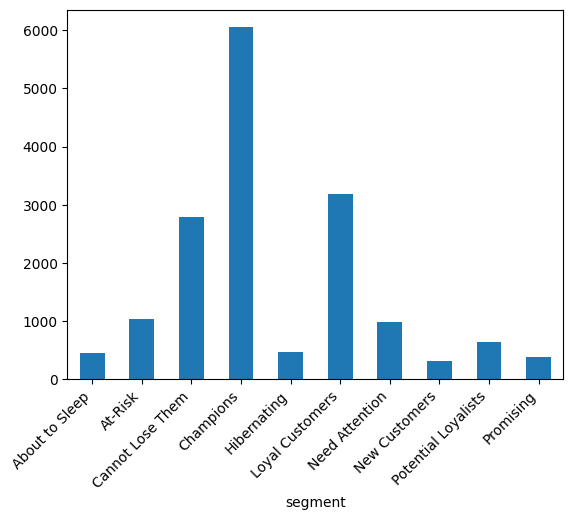

In [51]:
# Đánh giá giá trị kinh tế của các phân khúc khách hàng để xác định được nhóm Champions và Loyal Customers làm nhóm khách hàng chủ chốt
rfm.groupby('segment')['Monetary'].mean().plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.show()

In [31]:
# Phân tích sức nặng doanh thu của phân khúc Champions (=45%)
rfm[rfm['segment'] =='Champions']['Monetary'].sum()/rfm['Monetary'].sum()

np.float64(0.4505602056844732)

In [32]:
# Định danh hành vi khách hàng qua chỉ số RFM_Score tổng hợp
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score,segment,rfm_score
CustomerID,,,,,,,,,
12346,316,1,77183.60,1,5,1,11,Hibernating,115
12347,30,6,4085.18,4,5,5,45,Loyal Customers,455
12348,66,4,1797.24,3,4,4,34,Loyal Customers,344
12349,9,1,1757.55,5,4,1,51,New Customers,514
12350,301,1,334.40,1,2,1,11,Hibernating,112


In [33]:
# Đặc điểm phân khúc Champions
champions = rfm[rfm['segment']=='Champions']
champions.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score,segment,rfm_score
CustomerID,,,,,,,,,
12380,12,4,2724.81,5,5,4,54,Champions,545
12388,6,6,2780.66,5,5,5,55,Champions,555
12395,10,12,3018.63,5,5,5,55,Champions,555
12421,6,4,807.04,5,3,4,54,Champions,543
12437,12,16,4493.10,5,5,5,55,Champions,555


In [34]:
# Phân tích cấu trúc nội bộ phân khúc Champions
champions['rfm_score'].value_counts()

rfm_score
555    308
544    104
554     84
543     64
545     38
542     12
553      7
541      1
552      1
551      1
Name: count, dtype: int64

In [35]:
# Chuẩn hóa dữ liệu đầu vào cho mô hình dự báo
# Chỉ dùng bản giao dịch hợp lệ cho EDA churn; phần make_snapshot sẽ dùng df_full để giữ feature hành vi hủy/trả
df_model_base = df1.copy()
df_model_base['invoice_date'] = pd.to_datetime(df_model_base['invoice_date'])
df_model_base['customer_id'] = df_model_base['customer_id'].astype(int)

if 'total_price' not in df_model_base.columns:
    df_model_base['total_price'] = df_model_base['quantity'] * df_model_base['unit_price']

df_model_base = df_model_base.sort_values(['customer_id', 'invoice_date']).copy()

print("Min date:", df_model_base['invoice_date'].min())
print("Max date:", df_model_base['invoice_date'].max())
print("Unique customers:", df_model_base['customer_id'].nunique())

Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00
Unique customers: 4338


## **CHURN**
### **EDA Chứng minh định nghĩa CHURN 90 ngày**

PHÂN TÍCH KHOẢNG CÁCH MUA HÀNG (INTER-PURCHASE TIME)
Trung vị (Median): 0.0 ngày
75% khách hàng quay lại trong vòng: 0.0 ngày
90% khách hàng quay lại trong vòng: 0.0 ngày


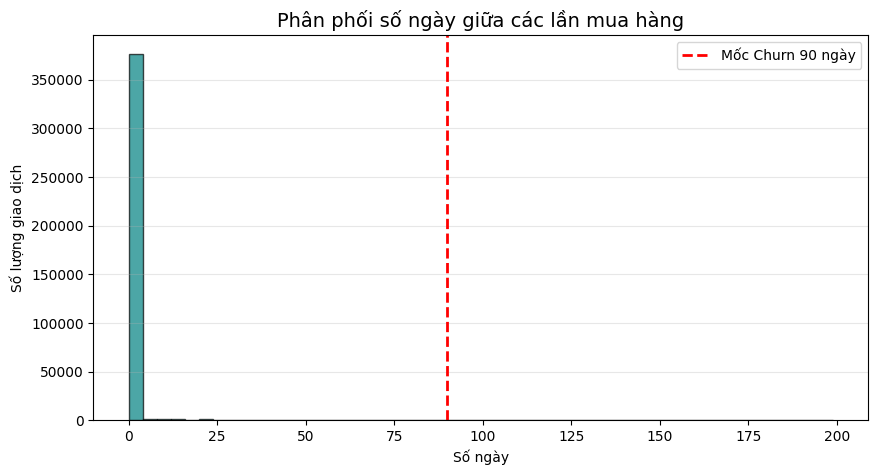

In [52]:
# 1. Tính inter-purchase time ở cấp độ đơn hàng (invoice-level) để tránh nhiễu do nhiều line item trong cùng một hóa đơn
orders_ipt = (
    df1[['customer_id', 'invoice_no', 'invoice_date']]
    .drop_duplicates()
    .sort_values(['customer_id', 'invoice_date'])
    .copy()
)

orders_ipt['prev_date'] = orders_ipt.groupby('customer_id')['invoice_date'].shift(1)
orders_ipt['days_between'] = (orders_ipt['invoice_date'] - orders_ipt['prev_date']).dt.days

# 2. Loại bỏ NaN và các khoảng cách bằng 0 nếu phát sinh nhiều invoice cùng ngày
ipt_values = orders_ipt['days_between'].dropna()
ipt_values = ipt_values[ipt_values > 0]

# 3. Tính các phân vị quan trọng để biện minh mốc churn 90 ngày
median_ipt = ipt_values.median()
p75_ipt = ipt_values.quantile(0.75)
p90_ipt = ipt_values.quantile(0.90)

print("PHÂN TÍCH KHOẢNG CÁCH MUA HÀNG (INTER-PURCHASE TIME)")
print(f"Median IPT: {median_ipt:.2f} ngày")
print(f"P75 IPT:    {p75_ipt:.2f} ngày")
print(f"P90 IPT:    {p90_ipt:.2f} ngày")
print("\nDiễn giải:")
print("- 75% khách hàng quay lại trong vòng khoảng", round(p75_ipt, 2), "ngày")
print("- 90% khách hàng quay lại trong vòng khoảng", round(p90_ipt, 2), "ngày")
print("- Vì vậy, mốc 90 ngày là một ngưỡng bảo thủ và hợp lý để định nghĩa churn.")

# 4. Vẽ biểu đồ phân phối
plt.figure(figsize=(10, 5))
plt.hist(ipt_values[ipt_values < 200], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(90, color='red', linestyle='--', linewidth=2, label='Mốc churn 90 ngày')
plt.title("Phân phối số ngày giữa các lần mua hàng (invoice-level)", fontsize=14)
plt.xlabel("Số ngày")
plt.ylabel("Số lượng khoảng cách mua")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### **Thiết lập cửa sổ quan sát và Feature Engineering nâng cao (với ngưỡng thống kê)**

In [ ]:
def safe_div(a, b):
    if pd.isna(b) or b == 0:
        return np.nan
    return a / b

def calc_order_level_dates(group):
    """Lấy lịch sử mua theo cấp invoice để tính IPT chính xác."""
    tmp = (
        group[['invoice_no', 'invoice_date']]
        .drop_duplicates()
        .sort_values('invoice_date')
        .copy()
    )
    return tmp

def calc_ipt_features(group, cutoff):
    orders = calc_order_level_dates(group)
    dates = orders['invoice_date'].sort_values()

    avg_interval = np.nan
    med_interval = np.nan
    std_interval = np.nan
    churn_threshold_stat = np.nan
    is_exceeding_threshold = 0

    if len(dates) >= 2:
        diffs = dates.diff().dropna().dt.days
        diffs = diffs[diffs > 0]
        if len(diffs) > 0:
            avg_interval = diffs.mean()
            med_interval = diffs.median()
            std_interval = diffs.std()

            sigma = std_interval if pd.notna(std_interval) else 0
            churn_threshold_stat = avg_interval + (2 * sigma)

    recency_days = (cutoff - dates.max()).days
    if pd.notna(churn_threshold_stat):
        is_exceeding_threshold = int(recency_days > churn_threshold_stat)

    return pd.Series({
        'average_purchase_interval': avg_interval,
        'median_purchase_interval': med_interval,
        'std_purchase_interval': std_interval,
        'churn_threshold_stat': churn_threshold_stat,
        'is_exceeding_threshold': is_exceeding_threshold,
        'anomaly_drop_rate': safe_div(recency_days, avg_interval)
    })

def make_snapshot(df_full, cutoff, horizon_days=90, active_window_days=180):
    """
    Tạo snapshot tại một thời điểm cutoff:
    - Chỉ dùng dữ liệu <= cutoff để tính feature
    - Dùng dữ liệu trong (cutoff, cutoff + horizon] để gắn nhãn
    """
    cutoff = pd.Timestamp(cutoff)
    future_end = cutoff + pd.Timedelta(days=horizon_days)

    # 1) Tách dữ liệu quá khứ / tương lai
    obs_all = df_full[df_full['invoice_date'] <= cutoff].copy()
    future = df_full[(df_full['invoice_date'] > cutoff) & (df_full['invoice_date'] <= future_end)].copy()

    # Leakage checks
    assert obs_all['invoice_date'].max() <= cutoff, "Leakage: observation window chứa dữ liệu sau cutoff."
    if len(future) > 0:
        assert future['invoice_date'].min() > cutoff, "Leakage: future window chồng lên observation window."

    # 2) Chỉ dự báo trên active customers
    active_start = cutoff - pd.Timedelta(days=active_window_days)
    active_ids = obs_all[obs_all['invoice_date'] > active_start]['customer_id'].unique()
    obs_all = obs_all[obs_all['customer_id'].isin(active_ids)].copy()

    if obs_all.empty:
        return pd.DataFrame()

    # 3) Hành vi hủy / trả hàng: GIỮ LẠI để tạo feature
    behavior_feat = obs_all.groupby('customer_id').agg(
        cancel_invoice_count=('is_cancel', 'sum'),
        return_txn_count=('is_return', 'sum'),
        total_return_amount=('total_amount', lambda x: abs(x[x < 0].sum())),
        total_gross_spend=('total_amount', lambda x: x[x > 0].sum())
    ).reset_index()

    behavior_feat['return_amount_ratio'] = (
        behavior_feat['total_return_amount'] / (behavior_feat['total_gross_spend'] + 0.01)
    )
    behavior_feat['cancel_rate'] = behavior_feat['cancel_invoice_count'] / (behavior_feat['cancel_invoice_count'] + 1)

    # 4) Tập giao dịch hợp lệ để tính RFM / monetary features
    obs = obs_all[
        (obs_all['quantity'] > 0) &
        (obs_all['unit_price'] > 0) &
        (~obs_all['is_cancel'])
    ].copy()

    if obs.empty:
        return pd.DataFrame()

    obs['total_price'] = obs['quantity'] * obs['unit_price']

    # 5) RFM + basket size
    rfm_feat = obs.groupby('customer_id').agg(
        recency=('invoice_date', lambda x: (cutoff - x.max()).days),
        frequency=('invoice_no', 'nunique'),
        monetary=('total_price', 'sum'),
        basket_size=('quantity', 'mean')
    ).reset_index()

    # 6) Average order value
    order_value = (
        obs.groupby(['customer_id', 'invoice_no'], as_index=False)['total_price'].sum()
        .groupby('customer_id', as_index=False)['total_price'].mean()
        .rename(columns={'total_price': 'avg_order_value'})
    )

    # 7) Velocity features
    period_30 = cutoff - pd.Timedelta(days=30)
    period_90 = cutoff - pd.Timedelta(days=90)

    def velocity_block(g):
        orders_30 = g[g['invoice_date'] > period_30]['invoice_no'].nunique()
        orders_prev = g[(g['invoice_date'] > period_90) & (g['invoice_date'] <= period_30)]['invoice_no'].nunique()
        spend_30 = g[g['invoice_date'] > period_30]['total_price'].sum()
        spend_prev = g[(g['invoice_date'] > period_90) & (g['invoice_date'] <= period_30)]['total_price'].sum()
        return pd.Series({
            'orders_last_30d': orders_30,
            'orders_prev_60d': orders_prev,
            'spend_last_30d': spend_30,
            'spend_prev_60d': spend_prev
        })

    velocity = obs.groupby('customer_id').apply(velocity_block).reset_index()
    if 'level_1' in velocity.columns:
        velocity = velocity.drop(columns=['level_1'])

    velocity['order_slope'] = velocity['orders_last_30d'] - (velocity['orders_prev_60d'] / 2)
    velocity['spend_slope'] = velocity['spend_last_30d'] - (velocity['spend_prev_60d'] / 2)

    # 8) IPT features
    ipt_feat = obs.groupby('customer_id').apply(lambda g: calc_ipt_features(g, cutoff)).reset_index()
    if 'level_1' in ipt_feat.columns:
        ipt_feat = ipt_feat.drop(columns=['level_1'])

    # 9) Merge feature table
    features = (
        rfm_feat
        .merge(order_value, on='customer_id', how='left')
        .merge(velocity, on='customer_id', how='left')
        .merge(ipt_feat, on='customer_id', how='left')
        .merge(
            behavior_feat[['customer_id', 'cancel_invoice_count', 'return_txn_count', 'return_amount_ratio', 'cancel_rate']],
            on='customer_id',
            how='left'
        )
    )

    for col in ['cancel_invoice_count', 'return_txn_count', 'return_amount_ratio', 'cancel_rate']:
        features[col] = features[col].fillna(0)

    features['anomaly_drop_rate'] = features['anomaly_drop_rate'].fillna(1.0)
    for col in ['average_purchase_interval', 'median_purchase_interval', 'std_purchase_interval']:
        features[col] = features[col].fillna(features[col].median())

    features['is_exceeding_threshold'] = features['is_exceeding_threshold'].fillna(0).astype(int)

    # 10) Gắn nhãn churn
    bought_in_future = set(
        future[(future['quantity'] > 0) & (~future['is_cancel'])]['customer_id'].unique()
    )
    features['churn_label'] = (~features['customer_id'].isin(bought_in_future)).astype(int)
    features['snapshot_date'] = cutoff
    features['future_end'] = future_end

    return features

# Alias để tương thích với các cell phía sau
build_snapshot = make_snapshot

> **Lưu ý sau khi sửa notebook:** phần churn/model ở cuối đã được chỉnh lại để khớp nhận xét mentor. Do file dữ liệu `Online_Retail.xlsx` không nằm trong notebook hiện tại nên các output cũ của phần này đã được xóa để tránh lệch source-output. Khi mở trên máy có dữ liệu, hãy **Restart & Run All** để sinh lại toàn bộ kết quả.

In [ ]:

# C. Xây nhiều snapshot để split theo thời gian

train_cutoffs = [
    pd.Timestamp('2011-05-31'),
    pd.Timestamp('2011-06-30'),
    pd.Timestamp('2011-07-31'),
    pd.Timestamp('2011-08-31')
]

# Holdout snapshot đúng với hướng báo cáo của nhóm
test_cutoff = pd.Timestamp('2011-09-09')

all_cutoffs = train_cutoffs + [test_cutoff]

snapshot_list = []

for c in all_cutoffs:
    print(f"--- Đang xử lý Snapshot: {c.date()} ---")

    # GỌI HÀM: build_snapshot bây giờ trả về 1 DataFrame duy nhất đã có đủ Feature & Label
    snap_df = make_snapshot(df_full, cutoff=c, horizon_days=90, active_window_days=180)

    if not snap_df.empty:
        snapshot_list.append(snap_df)
        print(f"Hoàn thành: {len(snap_df)} khách hàng.")

# Gộp tất cả thành bảng Master
model_df = pd.concat(snapshot_list, ignore_index=True)


In [ ]:
# D. Split theo thời gian (KHÔNG random split)

train_df = model_df[model_df['snapshot_date'] < test_cutoff].copy()
test_df  = model_df[model_df['snapshot_date'] == test_cutoff].copy()

assert train_df['snapshot_date'].max() < test_df['snapshot_date'].min(),     "Leakage: train và test không được chồng thời gian"

feature_cols = [
    'recency', 'frequency', 'monetary', 'basket_size', 'avg_order_value',
    'orders_last_30d', 'orders_prev_60d',
    'spend_last_30d', 'spend_prev_60d',
    'order_slope', 'spend_slope',
    'average_purchase_interval', 'median_purchase_interval',
    'std_purchase_interval', 'anomaly_drop_rate', 'is_exceeding_threshold',
    'cancel_invoice_count', 'return_txn_count', 'return_amount_ratio', 'cancel_rate'
]

X_train = train_df[feature_cols].copy()
y_train = train_df['churn_label'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['churn_label'].copy()

print("\n" + "="*30)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")
print("="*30)

In [ ]:

# E. Baseline Logistic Regression
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

print(f"Logistic Regression PR-AUC: {pr_auc_lr:.4f}")


In [ ]:

# F. XGBoost model

ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print(f"XGBoost PR-AUC: {pr_auc_xgb:.4f}")



In [ ]:

# G. Chọn model tốt hơn theo PR-AUC
if pr_auc_xgb >= pr_auc_lr:
    best_model_name = 'XGBoost'
    best_model = xgb_model
    y_prob = y_prob_xgb
else:
    best_model_name = 'Logistic Regression'
    best_model = lr_model
    y_prob = y_prob_lr

print(f"\nBest model = {best_model_name}")



In [ ]:
# H. Threshold tuning + cost table

# --- Business assumptions dùng cho scenario analysis ---
COST_INTERVENTION = 50_000   # Chi phí gọi / can thiệp cho 1 khách
VALUE_SAVED = 500_000        # Giá trị ròng kỳ vọng nếu giữ chân thành công 1 khách
P_SAVE = 0.25                # Xác suất giữ chân thành công sau can thiệp
CAPACITY = 300               # Năng lực CSKH tối đa mỗi kỳ

def threshold_search(y_true, y_prob, capacity, p_save, value_saved, cost_intervention, step=0.01):
    rows = []

    for th in np.round(np.arange(step, 0.96, step), 2):
        y_pred = (y_prob >= th).astype(int)

        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        tn = int(((y_pred == 0) & (y_true == 0)).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        contacted = tp + fp

        expected_profit = (tp * p_save * value_saved) - (contacted * cost_intervention)

        rows.append({
            "threshold": th,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision": precision,
            "recall": recall,
            "contacted": contacted,
            "profit": expected_profit
        })

    table = pd.DataFrame(rows).sort_values("threshold")
    feasible = table[table["contacted"] <= capacity]

    if not feasible.empty:
        best_row_local = feasible.loc[feasible["profit"].idxmax()]
    else:
        best_row_local = table.sort_values(["contacted", "profit"], ascending=[True, False]).iloc[0]

    return table, best_row_local

threshold_table, best_row = threshold_search(
    y_true=y_test,
    y_prob=y_prob,
    capacity=CAPACITY,
    p_save=P_SAVE,
    value_saved=VALUE_SAVED,
    cost_intervention=COST_INTERVENTION,
    step=0.01
)

best_thresh = float(best_row["threshold"])

print(f"=== Threshold comparison table (Capacity Limit: {CAPACITY}) ===")
display(threshold_table)

print(f"\nOptimal threshold (Feasible) = {best_thresh:.2f}")
print(f"Expected profit              = {best_row['profit']:,.0f} VNĐ")
print(f"Number of customers to call  = {int(best_row['contacted'])} / {CAPACITY}")

In [ ]:

# I. Evaluation tại threshold tối ưu

y_pred_opt = (y_prob >= best_thresh).astype(int)

print("\n=== Classification Report @ optimal threshold ===")
print(classification_report(y_test, y_pred_opt, target_names=['Active', 'Churn']))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

print(f"\nPR-AUC ({best_model_name}) = {average_precision_score(y_test, y_prob):.4f}")



In [ ]:

# J. Vẽ PR curve + Profit curve (ĐÃ CẬP NHẬT THEO LỖI 2)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Precision-Recall Curve
axes[0].plot(recalls[:-1], precisions[:-1], linewidth=2, color='darkblue')
axes[0].set_title(f'Precision-Recall Curve ({best_model_name})', fontsize=12)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].grid(True, alpha=0.3)

# 2. Biểu đồ Lợi nhuận theo Ngưỡng (Profit by Threshold)
# Vẽ đường lợi nhuận kỳ vọng
axes[1].plot(threshold_table['threshold'], threshold_table['profit'],
             marker='o', linestyle='-', color='gray', alpha=0.5, label='Expected Profit')

# Tô màu xanh cho Vùng khả thi (Năng lực gọi <= 300 khách)
# Giả định CAPACITY = 300 đã khai báo ở Mục H
axes[1].fill_between(threshold_table['threshold'],
                     threshold_table['profit'].min(),
                     threshold_table['profit'],
                     where=(threshold_table['contacted'] <= 300),
                     color='green', alpha=0.2, label='Vùng khả thi (<= 300 khách)')

# Vẽ đường thẳng tại ngưỡng tối ưu thực tế (best_thresh đã tính ở Mục H)
axes[1].axvline(best_thresh, linestyle='--', color='red',
                label=f'Ngưỡng tối ưu thực tế = {best_thresh:.2f}')

axes[1].set_title('Profit by Threshold & Capacity Constraint', fontsize=12)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Expected Profit (VNĐ)')
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# L. Scoring trên snapshot holdout để ra action list

test_df = test_df.copy()
test_df["churn_prob"] = y_prob

def classify_risk(p, threshold):
    if p >= 0.90:
        return "Lost Cause (>90%)"
    elif p >= threshold:
        return "Persuadable"
    elif p >= 0.30:
        return "At-Risk (Low)"
    else:
        return "Active"

test_df["risk_segment"] = test_df["churn_prob"].apply(lambda p: classify_risk(p, best_thresh))

print("\n=== Risk Segment Distribution ===")
print(test_df["risk_segment"].value_counts())

target_list = (
    test_df[test_df["risk_segment"] == "Persuadable"]
    .sort_values("churn_prob", ascending=False)
    [[
        "customer_id",
        "recency", "frequency", "monetary",
        "average_purchase_interval",
        "anomaly_drop_rate",
        "order_slope", "spend_slope",
        "cancel_invoice_count", "return_amount_ratio",
        "churn_prob"
    ]]
    .reset_index(drop=True)
)

print(f"\nSố khách hàng cần can thiệp theo threshold tối ưu: {len(target_list)}")
display(target_list.head(20))

In [ ]:
# M. Hồ sơ nhóm khách nguy cơ cao

high_risk_profile = (
    test_df.groupby("risk_segment")[[
        "recency", "frequency", "monetary",
        "average_purchase_interval", "anomaly_drop_rate",
        "order_slope", "spend_slope",
        "cancel_invoice_count", "return_amount_ratio"
    ]]
    .mean()
    .sort_index()
)

print("\n=== High Risk Profile ===")
display(high_risk_profile)

In [ ]:
# N. Bảng so sánh mô hình đầy đủ và trung thực

lr_threshold_table, lr_best = threshold_search(
    y_true=y_test,
    y_prob=y_prob_lr,
    capacity=CAPACITY,
    p_save=P_SAVE,
    value_saved=VALUE_SAVED,
    cost_intervention=COST_INTERVENTION,
    step=0.01
)

xgb_threshold_table, xgb_best = threshold_search(
    y_true=y_test,
    y_prob=y_prob_xgb,
    capacity=CAPACITY,
    p_save=P_SAVE,
    value_saved=VALUE_SAVED,
    cost_intervention=COST_INTERVENTION,
    step=0.01
)

model_comparison_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "PR-AUC": pr_auc_lr,
        "Best Threshold": float(lr_best["threshold"]),
        "Precision @ Best Th": float(lr_best["precision"]),
        "Recall @ Best Th": float(lr_best["recall"]),
        "Customers Contacted": int(lr_best["contacted"]),
        "Expected Profit": float(lr_best["profit"])
    },
    {
        "Model": "XGBoost",
        "PR-AUC": pr_auc_xgb,
        "Best Threshold": float(xgb_best["threshold"]),
        "Precision @ Best Th": float(xgb_best["precision"]),
        "Recall @ Best Th": float(xgb_best["recall"]),
        "Customers Contacted": int(xgb_best["contacted"]),
        "Expected Profit": float(xgb_best["profit"])
    }
]).sort_values(["PR-AUC", "Expected Profit"], ascending=False).reset_index(drop=True)

print("=== MODEL COMPARISON TABLE ===")
display(model_comparison_table)

In [ ]:
# N.1 Tóm tắt model winner để đưa vào báo cáo / slide

summary_table = model_comparison_table.copy()
summary_table["PR-AUC"] = summary_table["PR-AUC"].map(lambda x: f"{x:.4f}")
summary_table["Best Threshold"] = summary_table["Best Threshold"].map(lambda x: f"{x:.2f}")
summary_table["Precision @ Best Th"] = summary_table["Precision @ Best Th"].map(lambda x: f"{x:.4f}")
summary_table["Recall @ Best Th"] = summary_table["Recall @ Best Th"].map(lambda x: f"{x:.4f}")
summary_table["Expected Profit"] = summary_table["Expected Profit"].map(lambda x: f"{x:,.0f}")

winner_row = model_comparison_table.iloc[0]

print("=== SUMMARY TABLE ===")
display(summary_table)

print(
    f"\nModel được ưu tiên báo cáo: {winner_row['Model']} | "
    f"PR-AUC = {winner_row['PR-AUC']:.4f} | "
    f"Best Threshold = {winner_row['Best Threshold']:.2f} | "
    f"Customers Contacted = {int(winner_row['Customers Contacted'])} | "
    f"Expected Profit = {winner_row['Expected Profit']:,.0f} VNĐ"
)

## **Bổ sung theo nhận xét mentor: Top-K, mapping hành động, sensitivity analysis và walk-forward validation**

In [ ]:
# O. Top-K metrics theo Capacity (đội marketing chỉ chăm sóc được K khách)

def topk_metrics(y_true, y_prob, k):
    y_true_arr = np.array(y_true)
    y_prob_arr = np.array(y_prob)

    k = min(k, len(y_true_arr))
    top_idx = np.argsort(-y_prob_arr)[:k]

    tp_topk = int(y_true_arr[top_idx].sum())
    total_positive = int(y_true_arr.sum())

    precision_at_k = tp_topk / k if k > 0 else 0
    recall_at_k = tp_topk / total_positive if total_positive > 0 else 0

    return {
        "K": k,
        "TP@K": tp_topk,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k
    }

topk_best_model = topk_metrics(y_test, y_prob, CAPACITY)
topk_lr = topk_metrics(y_test, y_prob_lr, CAPACITY)
topk_xgb = topk_metrics(y_test, y_prob_xgb, CAPACITY)

topk_table = pd.DataFrame([
    {"Model": "Logistic Regression", **topk_lr},
    {"Model": "XGBoost", **topk_xgb}
])

topk_target_list = (
    test_df.sort_values("churn_prob", ascending=False)
    .head(CAPACITY)
    [[
        "customer_id",
        "churn_prob",
        "recency", "frequency", "monetary",
        "cancel_invoice_count", "return_amount_ratio"
    ]]
    .reset_index(drop=True)
)

print(f"=== TOP-K METRICS (K = {CAPACITY}) ===")
display(topk_table)

print(f"\nBest model hiện tại: {best_model_name}")
print(f"Precision@{CAPACITY}: {topk_best_model['Precision@K']:.4f}")
print(f"Recall@{CAPACITY}:    {topk_best_model['Recall@K']:.4f}")
print(f"TP@{CAPACITY}:        {topk_best_model['TP@K']}")

print(f"\n=== TOP {CAPACITY} CUSTOMERS TO PRIORITIZE ===")
display(topk_target_list.head(20))

In [ ]:
# P. Feature importance -> Hành động marketing cụ thể

feature_action_map = {
    "recency": "Khách đã lâu chưa quay lại -> gửi voucher quay lại hoặc reminder email",
    "frequency": "Khách từng mua thường xuyên -> ưu tiên retention tier cao",
    "monetary": "Khách giá trị cao -> ưu tiên ngân sách chăm sóc giữ chân",
    "basket_size": "Giỏ hàng nhỏ dần -> gợi ý combo / cross-sell",
    "avg_order_value": "Giá trị đơn giảm -> kích hoạt bundle hoặc upsell",
    "orders_last_30d": "Đơn gần đây giảm -> tái kích hoạt bằng email hoặc coupon",
    "orders_prev_60d": "Dùng để so sánh nhịp mua hiện tại với lịch sử",
    "spend_last_30d": "Chi tiêu gần đây giảm -> ưu đãi giá trị đơn hàng",
    "spend_prev_60d": "Đặt nền để đo xu hướng giảm chi tiêu",
    "order_slope": "Tần suất mua đang giảm -> cảnh báo retention sớm",
    "spend_slope": "Chi tiêu đang giảm -> ưu tiên campaign hồi phục doanh thu",
    "average_purchase_interval": "Chu kỳ mua trung bình cá nhân -> chuẩn hóa hành vi mua",
    "median_purchase_interval": "Trung vị chu kỳ mua -> bền vững hơn mean khi có nhiễu",
    "std_purchase_interval": "Chu kỳ mua biến động mạnh -> theo dõi khách thất thường",
    "anomaly_drop_rate": "Khách vắng mặt lâu bất thường -> cảnh báo đỏ sớm",
    "is_exceeding_threshold": "Khách đã vượt ngưỡng cá nhân hóa -> cần can thiệp ngay",
    "cancel_invoice_count": "Khách hủy đơn nhiều -> kiểm tra ma sát thanh toán / trải nghiệm mua",
    "return_txn_count": "Khách có nhiều lần trả hàng -> cần xem lại trải nghiệm / sản phẩm",
    "return_amount_ratio": "Khách trả hàng nhiều -> CSKH gọi hỏi nguyên nhân / vấn đề sản phẩm",
    "cancel_rate": "Tỷ lệ hủy cao -> ưu tiên xử lý friction trong funnel"
}

if best_model_name == "XGBoost":
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    })
else:
    lr_clf = best_model.named_steps["clf"]
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": np.abs(lr_clf.coef_[0])
    })

importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

feature_action_table = importance_df.copy()
feature_action_table["Recommended Action"] = feature_action_table["feature"].map(feature_action_map).fillna(
    "Cần phân tích thêm ý nghĩa business"
)

print("=== FEATURE IMPORTANCE ===")
display(importance_df.head(15))

print("\n=== FEATURE -> ACTION TABLE ===")
display(feature_action_table.head(12))

In [ ]:
# Q. Sensitivity analysis: so sánh horizon 60 ngày và 90 ngày

def fit_two_models_and_compare(X_train, y_train, X_test, y_test):
    lr_model_local = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ])
    lr_model_local.fit(X_train, y_train)
    y_prob_lr_local = lr_model_local.predict_proba(X_test)[:, 1]
    pr_auc_lr_local = average_precision_score(y_test, y_prob_lr_local)

    ratio_local = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    xgb_model_local = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=ratio_local,
        eval_metric="aucpr",
        random_state=42
    )
    xgb_model_local.fit(X_train, y_train)
    y_prob_xgb_local = xgb_model_local.predict_proba(X_test)[:, 1]
    pr_auc_xgb_local = average_precision_score(y_test, y_prob_xgb_local)

    return {
        "lr_model": lr_model_local,
        "xgb_model": xgb_model_local,
        "y_prob_lr": y_prob_lr_local,
        "y_prob_xgb": y_prob_xgb_local,
        "pr_auc_lr": pr_auc_lr_local,
        "pr_auc_xgb": pr_auc_xgb_local
    }

def run_one_horizon(horizon_days, cutoffs, test_cutoff_local):
    snap_list = []
    for c in cutoffs:
        snap_df = make_snapshot(df_full, cutoff=c, horizon_days=horizon_days, active_window_days=180)
        if not snap_df.empty:
            snap_list.append(snap_df)

    temp_df = pd.concat(snap_list, ignore_index=True)

    train_temp = temp_df[temp_df["snapshot_date"] < test_cutoff_local].copy()
    test_temp = temp_df[temp_df["snapshot_date"] == test_cutoff_local].copy()

    X_train_temp = train_temp[feature_cols].copy()
    y_train_temp = train_temp["churn_label"].copy()
    X_test_temp = test_temp[feature_cols].copy()
    y_test_temp = test_temp["churn_label"].copy()

    fit_out = fit_two_models_and_compare(X_train_temp, y_train_temp, X_test_temp, y_test_temp)

    if fit_out["pr_auc_xgb"] >= fit_out["pr_auc_lr"]:
        chosen_model = "XGBoost"
        chosen_prob = fit_out["y_prob_xgb"]
        chosen_prauc = fit_out["pr_auc_xgb"]
    else:
        chosen_model = "Logistic Regression"
        chosen_prob = fit_out["y_prob_lr"]
        chosen_prauc = fit_out["pr_auc_lr"]

    _, best_row_local = threshold_search(
        y_true=y_test_temp,
        y_prob=chosen_prob,
        capacity=CAPACITY,
        p_save=P_SAVE,
        value_saved=VALUE_SAVED,
        cost_intervention=COST_INTERVENTION,
        step=0.01
    )

    return {
        "Horizon": horizon_days,
        "Test Churn Rate": y_test_temp.mean(),
        "Best Model": chosen_model,
        "PR-AUC": chosen_prauc,
        "Best Threshold": float(best_row_local["threshold"]),
        "Customers Contacted": int(best_row_local["contacted"]),
        "Expected Profit": float(best_row_local["profit"])
    }

sensitivity_table = pd.DataFrame([
    run_one_horizon(60, all_cutoffs, test_cutoff),
    run_one_horizon(90, all_cutoffs, test_cutoff)
])

print("=== SENSITIVITY ANALYSIS: 60 vs 90 DAYS ===")
display(sensitivity_table)

In [ ]:
# R. Walk-forward validation để kiểm tra độ ổn định qua nhiều kỳ test

available_cutoffs = [
    pd.Timestamp("2011-05-31"),
    pd.Timestamp("2011-06-30"),
    pd.Timestamp("2011-07-31"),
    pd.Timestamp("2011-08-31"),
    pd.Timestamp("2011-09-09")
]

def run_walk_forward_one_test(test_cutoff_local, horizon_days=90):
    train_cutoffs_local = [c for c in available_cutoffs if c < test_cutoff_local]
    cutoffs_local = train_cutoffs_local + [test_cutoff_local]

    snap_list = []
    for c in cutoffs_local:
        snap_df = make_snapshot(df_full, cutoff=c, horizon_days=horizon_days, active_window_days=180)
        if not snap_df.empty:
            snap_list.append(snap_df)

    temp_df = pd.concat(snap_list, ignore_index=True)

    train_temp = temp_df[temp_df["snapshot_date"] < test_cutoff_local].copy()
    test_temp = temp_df[temp_df["snapshot_date"] == test_cutoff_local].copy()

    X_train_temp = train_temp[feature_cols].copy()
    y_train_temp = train_temp["churn_label"].copy()
    X_test_temp = test_temp[feature_cols].copy()
    y_test_temp = test_temp["churn_label"].copy()

    fit_out = fit_two_models_and_compare(X_train_temp, y_train_temp, X_test_temp, y_test_temp)

    if fit_out["pr_auc_xgb"] >= fit_out["pr_auc_lr"]:
        chosen_model = "XGBoost"
        chosen_prob = fit_out["y_prob_xgb"]
        chosen_prauc = fit_out["pr_auc_xgb"]
    else:
        chosen_model = "Logistic Regression"
        chosen_prob = fit_out["y_prob_lr"]
        chosen_prauc = fit_out["pr_auc_lr"]

    _, best_row_local = threshold_search(
        y_true=y_test_temp,
        y_prob=chosen_prob,
        capacity=CAPACITY,
        p_save=P_SAVE,
        value_saved=VALUE_SAVED,
        cost_intervention=COST_INTERVENTION,
        step=0.01
    )

    return {
        "Test Snapshot": str(test_cutoff_local.date()),
        "Best Model": chosen_model,
        "PR-AUC": chosen_prauc,
        "Best Threshold": float(best_row_local["threshold"]),
        "Customers Contacted": int(best_row_local["contacted"]),
        "Expected Profit": float(best_row_local["profit"])
    }

walk_forward_results = pd.DataFrame([
    run_walk_forward_one_test(pd.Timestamp("2011-07-31"), horizon_days=90),
    run_walk_forward_one_test(pd.Timestamp("2011-08-31"), horizon_days=90),
    run_walk_forward_one_test(pd.Timestamp("2011-09-09"), horizon_days=90)
])

print("=== WALK-FORWARD VALIDATION RESULTS ===")
display(walk_forward_results)

stability_summary = pd.DataFrame({
    "Metric": ["Mean PR-AUC", "Std PR-AUC", "Mean Expected Profit", "Std Expected Profit"],
    "Value": [
        walk_forward_results["PR-AUC"].mean(),
        walk_forward_results["PR-AUC"].std(),
        walk_forward_results["Expected Profit"].mean(),
        walk_forward_results["Expected Profit"].std()
    ]
})

print("\n=== STABILITY SUMMARY ===")
display(stability_summary)